In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Output folder for vector figures ---
OUT_DIR = "test_images\\figures"
IN_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

# --- File patterns (edit if your names differ) ---
# Training/validation history files (one per model)
HISTORY_FILES = {i: os.path.join(IN_DIR, f"DeepD3_test_model_data_{i}.csv") for i in [1,2,3,4]}
RESULT_FILES  = {i: os.path.join(IN_DIR, f"results{i}.csv") for i in [1,2,3,4]}

# --- Matplotlib defaults (LaTeX-friendly & legible) ---
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,   # embed TrueType
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# "Model 1 (bs32, f8, e30, 50k)"
# "Model 2 (bs16, f16, e30, 15k)"
# "Model 3 (bs16, f16, e35, 20k)"
# "Model 4 (bs16, f32, e40, 30k)"
# --- Model styles (avoid red & green together; consistent across all plots) ---
MODEL_STYLES = {
    1: {"label": "Model 1",  "color": "#1f77b4", "ls": "-",  "marker": "o"},
    2: {"label": "Model 2", "color": "#ff7f0e", "ls": "--", "marker": "s"},
    3: {"label": "Model 3", "color": "#6a3d9a", "ls": ":",  "marker": "D"},
    4: {"label": "Model 4", "color": "#17becf", "ls": "-.", "marker": "^"},
}

# --- Column resolver helpers (robust to naming variants) ---
def get_col(df, *candidates, required=True, default=None):
    cols = {c.lower(): c for c in df.columns}
    for name in candidates:
        name_l = name.lower()
        if name_l in cols:
            return df[cols[name_l]]
    if required:
        raise KeyError(f"None of the columns {candidates} found. Available: {list(df.columns)}")
    return default

def load_history(path):
    df = pd.read_csv(path)
    # Make sure epoch exists or synthesize a 0..N-1 index
    if "epoch" not in {c.lower(): c for c in df.columns}:
        df = df.copy()
        df["epoch"] = np.arange(len(df))
    # Normalize casing by just returning df as-is
    return df

def load_results(path):
    return pd.read_csv(path)

# Load everything into memory
histories = {}
for mid, f in HISTORY_FILES.items():
    histories[mid] = load_history(f)

results = {}
for mid, f in RESULT_FILES.items():
    results[mid] = load_results(f)

print("Loaded:", {
    "histories": {k: histories[k].shape for k in histories},
    "results": {k: results[k].shape for k in results},
})

Loaded: {'histories': {1: (35, 11), 2: (30, 11), 3: (32, 11), 4: (25, 11)}, 'results': {1: (27, 9), 2: (27, 9), 3: (27, 9), 4: (27, 9)}}


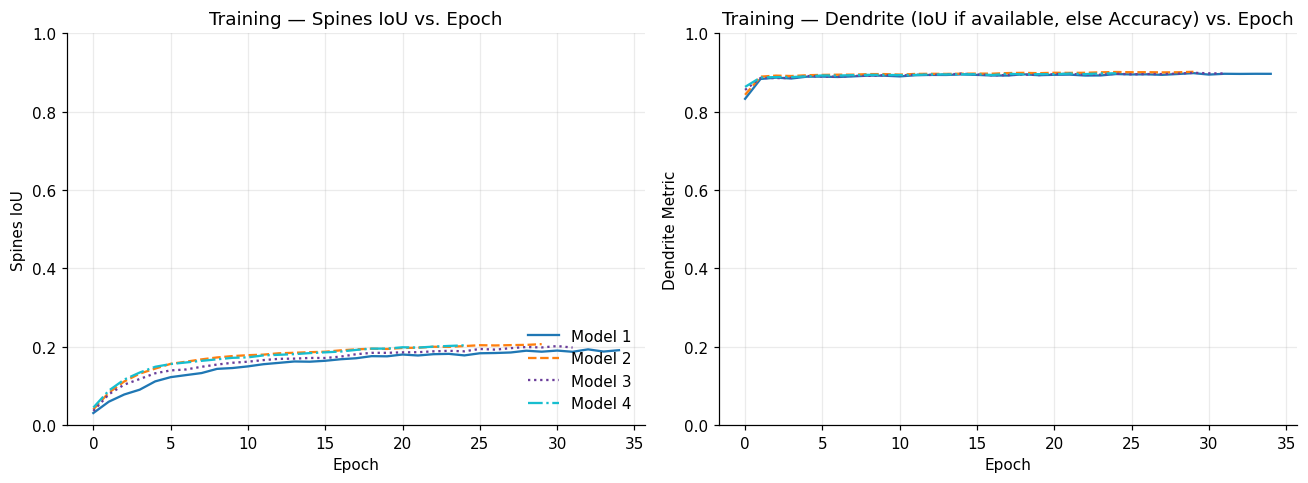

In [8]:
# Cell 2: Training metrics vs epoch (Spines IoU and Dendrite metric)

# Try to find dendrite IoU; else fall back to dendrite accuracy
def get_train_spines_iou(df):
    return get_col(df, "spines_iou_score", "spines_iou", "sp_iou", "iou_spines")

def get_train_dendrite_metric(df):
    # Prefer IoU if present, else dendrite accuracy
    try:
        return get_col(df, "dendrites_iou", "de_iou", required=True)
    except KeyError:
        return get_col(df, "dendrites_acc", "de_acc", "accuracy_dendrites", required=True)

# Figure 1: Training, left=Spines IoU, right=Dendrite (IoU or Acc)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

ax_sp, ax_de = axes
for mid, df in histories.items():
    epoch = get_col(df, "epoch")
    sp_iou = get_train_spines_iou(df)
    de_metric = get_train_dendrite_metric(df)
    style = MODEL_STYLES[mid]
    ax_sp.plot(epoch, sp_iou, label=style["label"], color=style["color"], ls=style["ls"])
    ax_de.plot(epoch, de_metric, label=style["label"], color=style["color"], ls=style["ls"])

ax_sp.set_title("Training — Spines IoU vs. Epoch")
ax_sp.set_xlabel("Epoch"); ax_sp.set_ylabel("Spines IoU"); ax_sp.set_ylim(0, 1)
ax_de.set_title("Training — Dendrite (IoU if available, else Accuracy) vs. Epoch")
ax_de.set_xlabel("Epoch"); ax_de.set_ylabel("Dendrite Metric"); ax_de.set_ylim(0, 1)

axes[0].legend(loc="lower right", ncol=1)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "train_spinesIOU_dendriteMetric.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "train_spinesIOU_dendriteMetric.svg"), bbox_inches="tight")
plt.show()


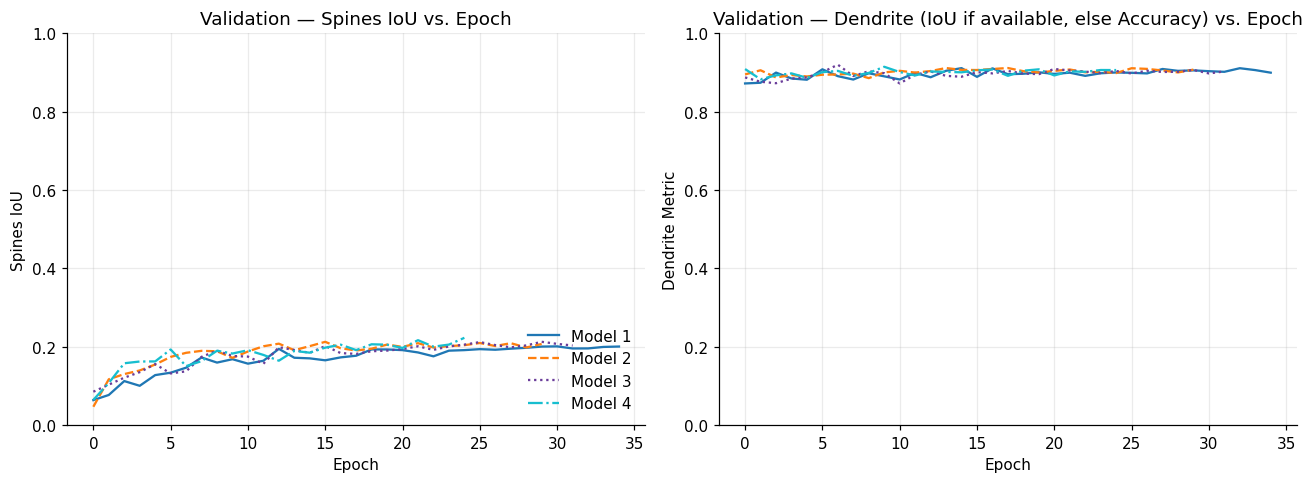

In [9]:
# Cell 3: Validation metrics vs epoch (Spines IoU and Dendrite metric)

def get_val_spines_iou(df):
    return get_col(df, "val_spines_iou_score", "val_spines_iou", "val_sp_iou")

def get_val_dendrite_metric(df):
    # Prefer IoU if present, else dendrite accuracy
    try:
        return get_col(df, "val_dendrites_iou", "val_de_iou", required=True)
    except KeyError:
        return get_col(df, "val_dendrites_acc", "val_de_acc", "val_accuracy_dendrites", required=True)

# Figure 2: Validation, left=Spines IoU, right=Dendrite (IoU or Acc)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

ax_sp, ax_de = axes
for mid, df in histories.items():
    epoch = get_col(df, "epoch")
    sp_iou = get_val_spines_iou(df)
    de_metric = get_val_dendrite_metric(df)
    style = MODEL_STYLES[mid]
    ax_sp.plot(epoch, sp_iou, label=style["label"], color=style["color"], ls=style["ls"])
    ax_de.plot(epoch, de_metric, label=style["label"], color=style["color"], ls=style["ls"])

ax_sp.set_title("Validation — Spines IoU vs. Epoch")
ax_sp.set_xlabel("Epoch"); ax_sp.set_ylabel("Spines IoU"); ax_sp.set_ylim(0, 1)
ax_de.set_title("Validation — Dendrite (IoU if available, else Accuracy) vs. Epoch")
ax_de.set_xlabel("Epoch"); ax_de.set_ylabel("Dendrite Metric"); ax_de.set_ylim(0, 1)

axes[0].legend(loc="lower right", ncol=1)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "val_spinesIOU_dendriteMetric.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "val_spinesIOU_dendriteMetric.svg"), bbox_inches="tight")
plt.show()


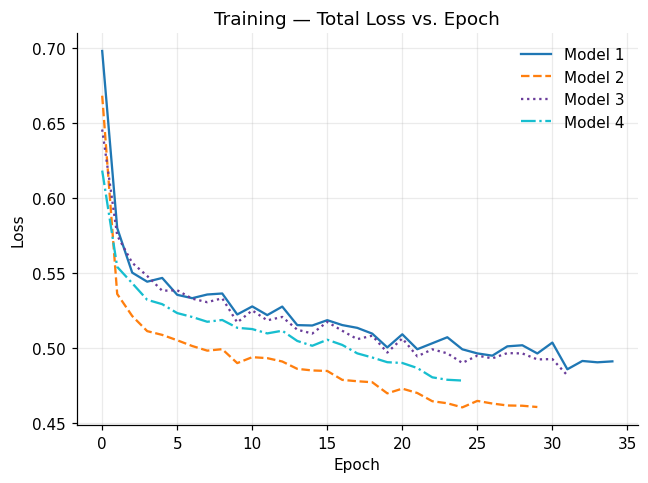

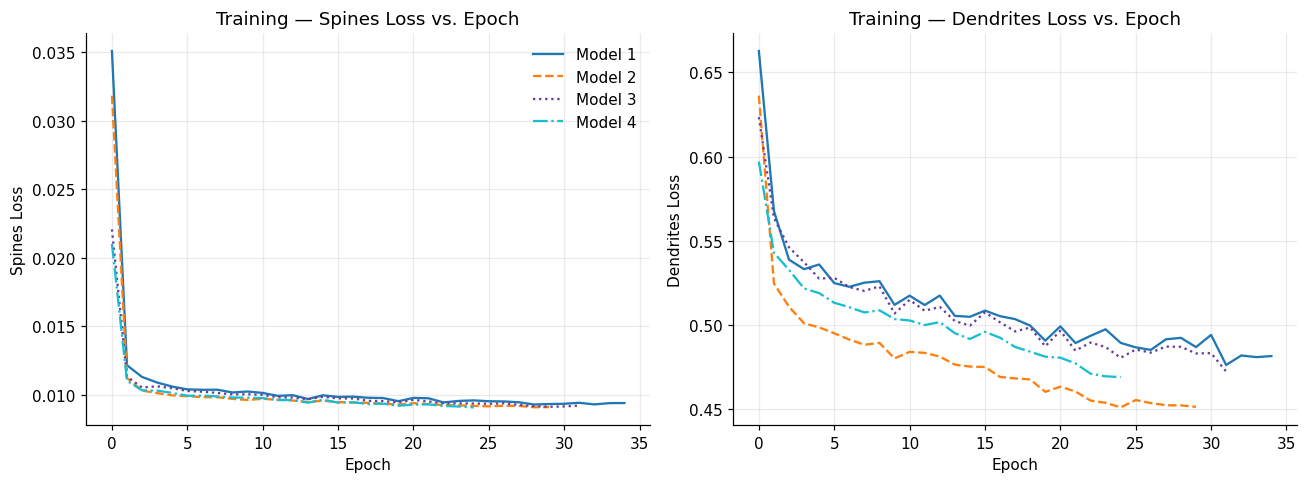

In [10]:
# Cell 4: Training loss vs epoch (total, spines_loss, dendrites_loss)

def get_train_total_loss(df):
    return get_col(df, "loss", "train_loss")

def get_train_spines_loss(df):
    return get_col(df, "spines_loss", "loss_spines", "train_spines_loss")

def get_train_dendrites_loss(df):
    return get_col(df, "dendrites_loss", "loss_dendrites", "train_dendrites_loss")

# Figure 3A: Total loss
fig, ax = plt.subplots(figsize=(6, 4.5))
for mid, df in histories.items():
    epoch = get_col(df, "epoch")
    loss = get_train_total_loss(df)
    style = MODEL_STYLES[mid]
    ax.plot(epoch, loss, label=style["label"], color=style["color"], ls=style["ls"])
ax.set_title("Training — Total Loss vs. Epoch")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "train_total_loss.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "train_total_loss.svg"), bbox_inches="tight")
plt.show()

# Figure 3B: Per-task losses (side-by-side subplots)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
ax_sp, ax_de = axes
for mid, df in histories.items():
    epoch = get_col(df, "epoch")
    sp_loss = get_train_spines_loss(df)
    de_loss = get_train_dendrites_loss(df)
    style = MODEL_STYLES[mid]
    ax_sp.plot(epoch, sp_loss, label=style["label"], color=style["color"], ls=style["ls"])
    ax_de.plot(epoch, de_loss, label=style["label"], color=style["color"], ls=style["ls"])

ax_sp.set_title("Training — Spines Loss vs. Epoch")
ax_sp.set_xlabel("Epoch"); ax_sp.set_ylabel("Spines Loss")
ax_de.set_title("Training — Dendrites Loss vs. Epoch")
ax_de.set_xlabel("Epoch"); ax_de.set_ylabel("Dendrites Loss")

axes[0].legend(loc="upper right", ncol=1)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "train_per_task_losses.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "train_per_task_losses.svg"), bbox_inches="tight")
plt.show()


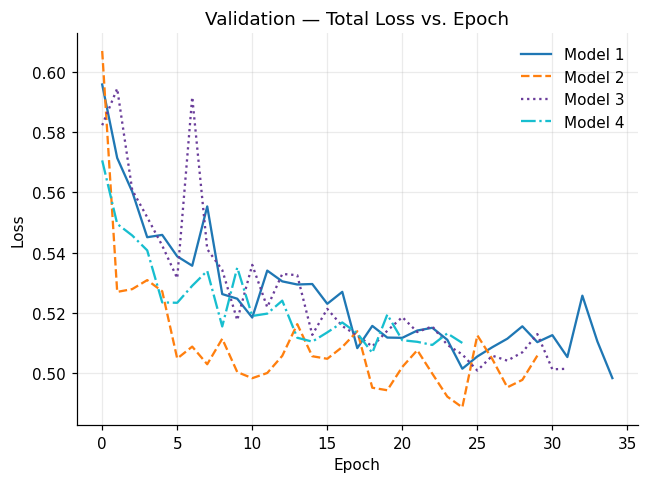

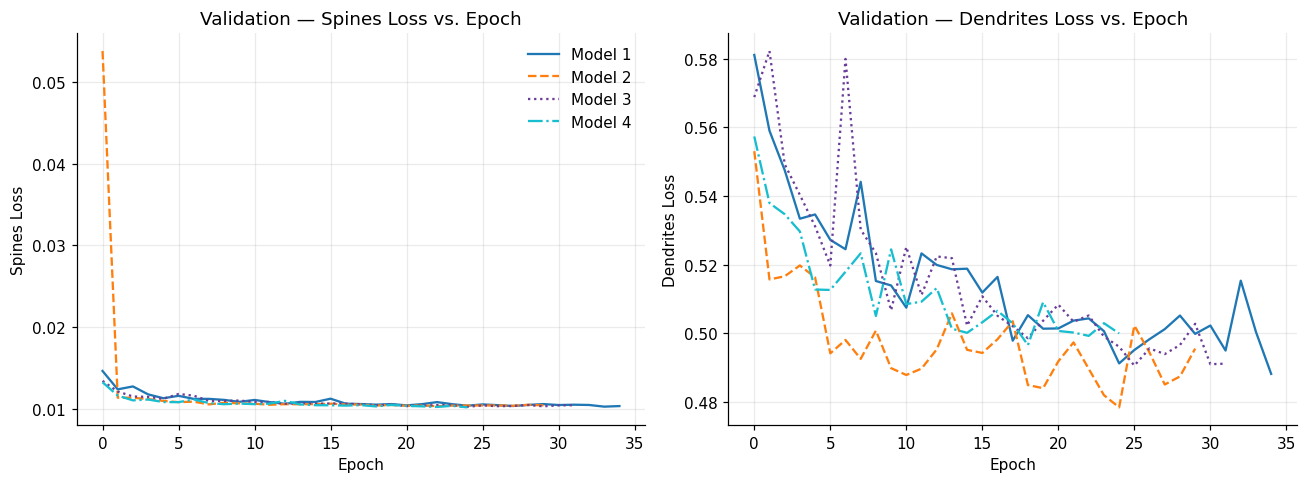

In [11]:
# Cell 5: Validation loss vs epoch (total, spines_loss, dendrites_loss)

def get_val_total_loss(df):
    return get_col(df, "val_loss")

def get_val_spines_loss(df):
    return get_col(df, "val_spines_loss")

def get_val_dendrites_loss(df):
    return get_col(df, "val_dendrites_loss")

# Figure 4A: Total val loss
fig, ax = plt.subplots(figsize=(6, 4.5))
for mid, df in histories.items():
    epoch = get_col(df, "epoch")
    loss = get_val_total_loss(df)
    style = MODEL_STYLES[mid]
    ax.plot(epoch, loss, label=style["label"], color=style["color"], ls=style["ls"])
ax.set_title("Validation — Total Loss vs. Epoch")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "val_total_loss.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "val_total_loss.svg"), bbox_inches="tight")
plt.show()

# Figure 4B: Per-task val losses (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
ax_sp, ax_de = axes
for mid, df in histories.items():
    epoch = get_col(df, "epoch")
    sp_loss = get_val_spines_loss(df)
    de_loss = get_val_dendrites_loss(df)
    style = MODEL_STYLES[mid]
    ax_sp.plot(epoch, sp_loss, label=style["label"], color=style["color"], ls=style["ls"])
    ax_de.plot(epoch, de_loss, label=style["label"], color=style["color"], ls=style["ls"])

ax_sp.set_title("Validation — Spines Loss vs. Epoch")
ax_sp.set_xlabel("Epoch"); ax_sp.set_ylabel("Spines Loss")
ax_de.set_title("Validation — Dendrites Loss vs. Epoch")
ax_de.set_xlabel("Epoch"); ax_de.set_ylabel("Dendrites Loss")

axes[0].legend(loc="upper right", ncol=1)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "val_per_task_losses.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "val_per_task_losses.svg"), bbox_inches="tight")
plt.show()


In [12]:
# Cell 6: Compute mean/std per model for test metrics

TEST_METRICS = {
    "Recall": {"sp": "sp_recall", "de": "de_recall"},
    "IoU":    {"sp": "sp_iou",    "de": "de_iou"},
    "NSD":    {"sp": "sp_nsd",    "de": "de_nsd"},
}

# Aggregate mean/std across cases (n=27)
agg = {}
for mid, df in results.items():
    stats = {}
    for group, mapping in TEST_METRICS.items():
        stats[group] = {
            "sp_mean": df[mapping["sp"]].mean(),
            "sp_std":  df[mapping["sp"]].std(ddof=1),
            "de_mean": df[mapping["de"]].mean(),
            "de_std":  df[mapping["de"]].std(ddof=1),
        }
    agg[mid] = stats

# Pretty table to inspect
rows = []
for mid in sorted(agg):
    for metric in ("Recall", "IoU", "NSD"):
        rows.append({
            "Model": mid,
            "Metric": metric,
            "Spines mean": agg[mid][metric]["sp_mean"],
            "Spines std":  agg[mid][metric]["sp_std"],
            "Dendrites mean": agg[mid][metric]["de_mean"],
            "Dendrites std":  agg[mid][metric]["de_std"],
        })
agg_df = pd.DataFrame(rows)
display(agg_df)


,Model,Metric,Spines mean,Spines std,Dendrites mean,Dendrites std
0,1,Recall,0.273798,0.083650,0.432925,0.178880
1,1,IoU,0.102134,0.034531,0.091529,0.091681
2,1,NSD,0.491724,0.148563,0.224050,0.125504
3,2,Recall,0.337953,0.088744,0.417936,0.183106
4,2,IoU,0.112428,0.036010,0.084063,0.092037
5,2,NSD,0.514149,0.147612,0.205516,0.127739
6,3,Recall,0.261006,0.075459,0.442460,0.184804
7,3,IoU,0.110232,0.036085,0.093321,0.095025
8,3,NSD,0.525053,0.156249,0.226138,0.131662
9,4,Recall,0.337953,0.088744,0.417936,0.183106


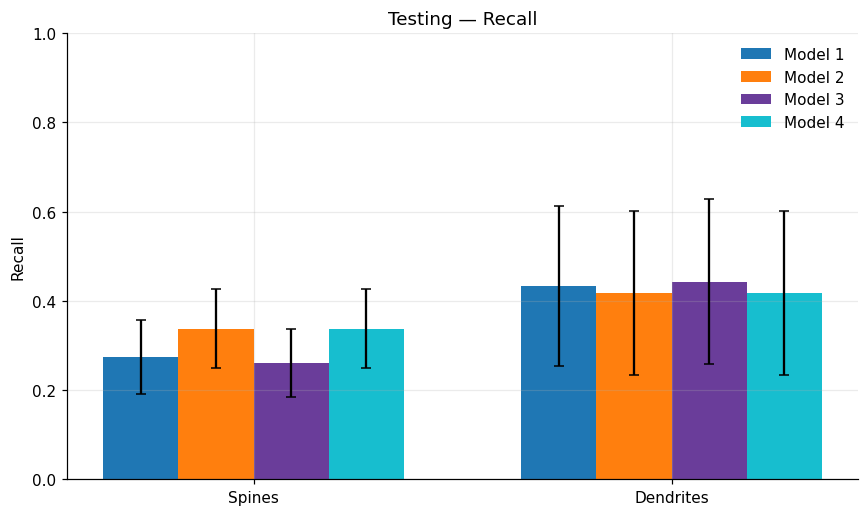

In [14]:
# Cell 7: Testing Recall — grouped bar chart with error bars (Sp vs De)

import math

def grouped_bar_with_error(ax, metric_name, ylabel="Score", ylim=(0,1)):
    # two groups on x: Spines, Dendrites
    groups = ["Spines", "Dendrites"]
    x = np.arange(len(groups))
    width = 0.18  # bar width per model

    # draw bars for each model
    for i, mid in enumerate(sorted(agg)):
        style = MODEL_STYLES[mid]
        means = [
            agg[mid][metric_name]["sp_mean"],
            agg[mid][metric_name]["de_mean"],
        ]
        stds = [
            agg[mid][metric_name]["sp_std"],
            agg[mid][metric_name]["de_std"],
        ]
        ax.bar(x + (i - 1.5)*width, means, width=width,
               yerr=stds, capsize=3, label=style["label"], color=style["color"])

    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Testing — {metric_name}")
    if ylim:
        ax.set_ylim(*ylim)

fig, ax = plt.subplots(figsize=(8, 4.8))
grouped_bar_with_error(ax, "Recall", ylabel="Recall", ylim=(0,1))
ax.legend(ncol=1, loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "test_recall_grouped.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "test_recall_grouped.svg"), bbox_inches="tight")
plt.show()


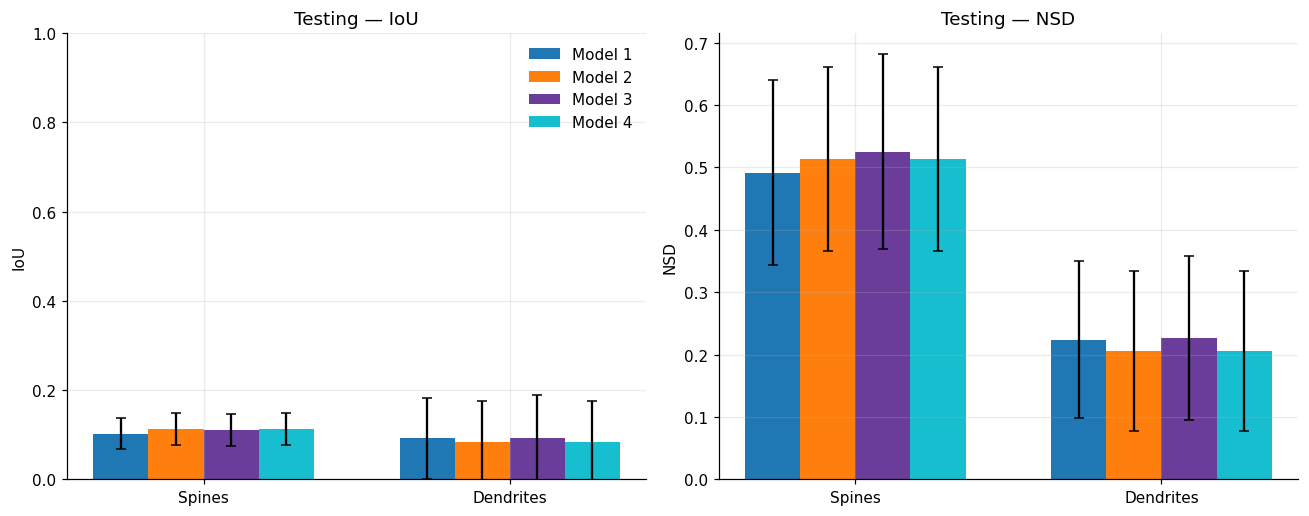

In [16]:
# Cell 8: Testing IoU and NSD — grouped bars with error bars, side-by-side

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

grouped_bar_with_error(axes[0], "IoU", ylabel="IoU", ylim=(0,1))
grouped_bar_with_error(axes[1], "NSD", ylabel="NSD", ylim=None)

axes[0].legend(ncol=1, loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "test_iou_nsd_grouped.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(OUT_DIR, "test_iou_nsd_grouped.svg"), bbox_inches="tight")
plt.show()
